In [167]:
# 导入必要库
import numpy as np
from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib import pyplot as plt


In [168]:
#导入中文模块
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [169]:
linnerud=load_linnerud()
X=linnerud.data# 获取特征数据
y=linnerud.target# 获取目标数据
features_name=linnerud.feature_names# 获取特征名称
target_name=linnerud.target_names# 获取目标名称
print(features_name,'\n',X[0:5])
print(target_name,'\n',y[0:5])
print(X.shape)

['Chins', 'Situps', 'Jumps'] 
 [[  5. 162.  60.]
 [  2. 110.  60.]
 [ 12. 101. 101.]
 [ 12. 105.  37.]
 [ 13. 155.  58.]]
['Weight', 'Waist', 'Pulse'] 
 [[191.  36.  50.]
 [189.  37.  52.]
 [193.  38.  58.]
 [162.  35.  62.]
 [189.  35.  46.]]
(20, 3)


In [170]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)#划分训练集和测试集
X_train.shape

(16, 3)

In [171]:
print("决策树")

# 存储结果
depth_dt=[i for i in range(1,11)]# 创建深度列表
r2_dt=[] # 存储R²分数
mse_dt=[] # 存储均方误差
for i in depth_dt:
    dt=DecisionTreeRegressor(max_depth=i,random_state=42)   # 创建决策树模型，设置最大深度为i
    dt.fit(X_train,y_train) # 训练模型
    y_pred=dt.predict(X_test)# 预测测试集
    r2_dt.append(r2_score(y_test, y_pred))# R²分数
    mse_dt.append(mean_squared_error(y_test, y_pred)) # MSE
    # 打印当前深度的结果
    print(f"depth: {i}")
    print(f"r2: {r2_score(y_test,y_pred)}")
    print(f"mse: {mean_squared_error(y_test,y_pred)}")

# 找出最佳深度
best_depth = depth_dt[np.argmax(r2_dt)]
best_r2=r2_dt[np.argmax(r2_dt)]
print(f"best depth: {best_depth}")  # 最佳深度
print(f"best_r2: {max(r2_dt)}")  # 最佳R²分数
print(f"mse: {min(mse_dt)}")  # 最佳深度对应的MSE

#网格搜索+交叉验证 查找最优超参数
dt_params = {'max_depth': [i for i in range(1,11)], 'min_samples_split': [2, 5]} #网格搜索+交叉验证，决策树算法所需要的参数。第一个表示树的最大深度，第二个表示内部节点再划分所需最小样本数
dt=DecisionTreeRegressor(random_state=42)
dt_grid=GridSearchCV(dt,dt_params,cv=8)# 网格搜索：自动测试最优参数组合，cv为5，5折交叉验证
dt_grid.fit(X_train,y_train)

dt_best=dt_grid.best_estimator_# 最佳参数组合的模型
dt_y_pred=dt_best.predict(X_test)# 用最佳模型预测
print(f"网格搜索交叉验证最佳参数：{dt_grid.best_params_}")
print(f"网格搜索交叉验证最佳r2：{dt_grid.best_score_}")
print(f"网格搜索交叉验证最佳mse: {mean_squared_error(y_test, dt_y_pred)}")

决策树
depth: 1
r2: -1.189977990751758
mse: 267.10666666666674
depth: 2
r2: -2.4562220152852494
mse: 417.8796296296296
depth: 3
r2: -2.226292601454402
mse: 359.90277777777777
depth: 4
r2: -2.239889365392745
mse: 321.0416666666667
depth: 5
r2: -2.2473142179743646
mse: 359.3333333333333
depth: 6
r2: -2.8388116749255823
mse: 371.9166666666667
depth: 7
r2: -2.8388116749255823
mse: 371.9166666666667
depth: 8
r2: -2.8388116749255823
mse: 371.9166666666667
depth: 9
r2: -2.8388116749255823
mse: 371.9166666666667
depth: 10
r2: -2.8388116749255823
mse: 371.9166666666667
best depth: 1
best_r2: -1.189977990751758
mse: 267.10666666666674
网格搜索交叉验证最佳参数：{'max_depth': 1, 'min_samples_split': 2}
网格搜索交叉验证最佳r2：-6.3657550492928
网格搜索交叉验证最佳mse: 267.10666666666674


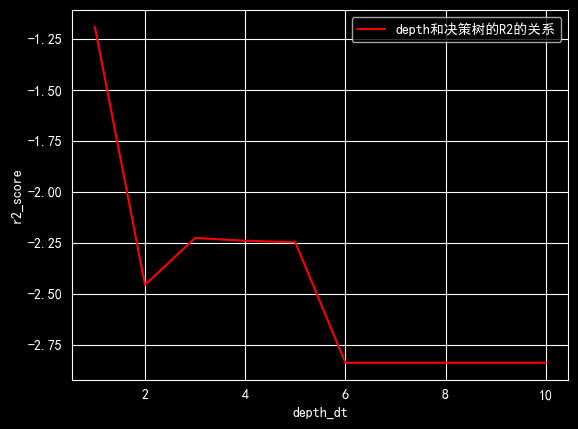

In [172]:
plt.figure()
plt.plot(depth_dt,r2_dt,'r',label="depth和决策树的R2的关系")
plt.xlabel("depth_dt")
plt.ylabel("r2_score")
plt.legend()
plt.show()

In [175]:
print("随机森林")
# 存储不同深度的结果
depth_rf = [i for i in range(1,11)]  # 创建深度列表：1到10
r2_rf = []  # 存储R²分数
mse_rf = []  # 存储均方误差

# 循环测试每个深度
for i in depth_rf:
    # 创建随机森林模型，设置最大深度和随机种子
    rf = RandomForestRegressor(max_depth=i, random_state=42)
    rf.fit(X_train, y_train)  # 训练模型
    y_pred = rf.predict(X_test)  # 预测测试集

    # 计算并存储评估指标
    r2_rf.append(r2_score(y_test, y_pred))  # R²分数（越大越好）
    mse_rf.append(mean_squared_error(y_test, y_pred))  # MSE（越小越好）

    # 打印当前深度的结果
    print(f"depth: {i}")
    print(f"r2: {r2_score(y_test, y_pred)}")
    print(f"mse: {mean_squared_error(y_test, y_pred)}")

# 找出最佳深度（R²最大对应的深度）
best_depth = depth_rf[np.argmax(r2_rf)]  # 获取最佳深度
best_r2 = r2_rf[np.argmax(r2_rf)]  # 获取最佳R²
print(f"best depth: {best_depth} \n best_r2: {max(r2_rf)} \n mse: {min(mse_rf)}")

#网格搜索+交叉验证 查找最优超参数
rf_params = {'n_estimators': [50, 100,150], 'max_depth': [i for i in range(1,11)]} #网格搜索+交叉验证，随机森林算法所需要的参数，第一个表示树的数量，第二个表示树的最大深度
rf=RandomForestRegressor(random_state=42)
rf_grid=GridSearchCV(rf,rf_params,cv=5)
rf_grid.fit(X_train,y_train)
rf_grid_best=rf_grid.best_estimator_
rf_y_pred=rf_grid_best.predict(X_test)
print(f"网格搜索交叉验证最佳参数：{rf_grid.best_params_}")
print(f"网格搜索交叉验证最佳r2：{rf_grid.best_score_}")
print(f"网格搜索交叉验证最佳mse: {mean_squared_error(y_test, rf_y_pred)}")

随机森林
depth: 1
r2: -0.5038057857992237
mse: 189.36032496967778
depth: 2
r2: -1.0034869324186964
mse: 247.7330549557397
depth: 3
r2: -1.0829180388220105
mse: 259.70028904427096
depth: 4
r2: -1.0773168223551346
mse: 249.36095182171232
depth: 5
r2: -1.0339346343754698
mse: 243.33648626110156
depth: 6
r2: -1.0455478136678658
mse: 242.75703416666684
depth: 7
r2: -1.055518633988381
mse: 242.75831666666667
depth: 8
r2: -1.055518633988381
mse: 242.75831666666667
depth: 9
r2: -1.055518633988381
mse: 242.75831666666667
depth: 10
r2: -1.055518633988381
mse: 242.75831666666667
best depth: 1 
 best_r2: -0.5038057857992237 
 mse: 189.36032496967778
网格搜索交叉验证最佳参数：{'max_depth': 1, 'n_estimators': 50}
网格搜索交叉验证最佳r2：-1.087243663453537
网格搜索交叉验证最佳mse: 220.68807580244535


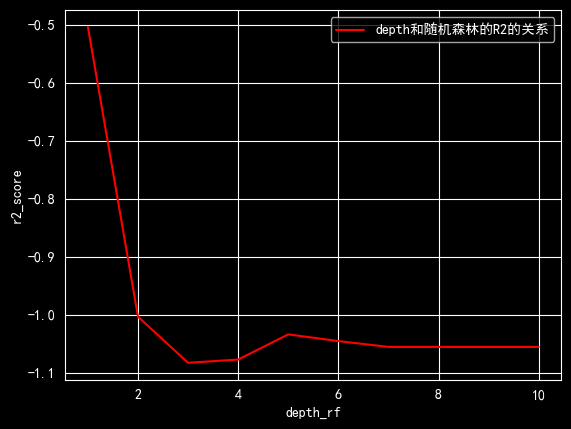

In [174]:
plt.figure()
plt.plot(depth_rf,r2_rf,'r',label="depth和随机森林的R2的关系")
plt.xlabel("depth_rf")
plt.ylabel("r2_score")
plt.legend()
plt.show()